# Benchmark: Tabular Baselines for Binary Retention Prediction

Predict **completed** (tier 4 vs tiers 1-3) using pre-trial clinical features
merged with 8-week engagement features (`features_w8.csv`).

Models:
1. **Logistic Regression** (with `StandardScaler`)
2. **Random Forest** (200 trees)

Evaluation: hold-out test set (80/20 stratified split) + 5-fold stratified CV.

## 1. Load & Merge Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA = '../../data/clean-data/'

pre = pd.read_csv(DATA + 'pre-trial.csv')
w8  = pd.read_csv(DATA + 'features_w8.csv')
ret = pd.read_csv(DATA + 'retention_tier.csv')

df = (
    pre
    .merge(w8,  on='PATID', how='inner')
    .merge(ret, on='PATID', how='inner')
)

print(f'Shape after merge: {df.shape}')
print('\nTarget distribution:')
print(df['completed'].value_counts().rename({0: 'Not completed (0)', 1: 'Completed (1)'}))
df.head(3)

Shape after merge: (554, 90)

Target distribution:
completed
Not completed (0)    333
Completed (1)        221
Name: count, dtype: int64


,PATID,last_opioid_date,last_substance_code,last_route_code,discharge_facility_code,detox_admission_day,detox_discharge_day,detox_los,last_substance_label,last_route_label,...,sow_restlessness_baseline,sow_nausea_baseline,sow_vomiting_baseline,sow_muscle_twitching_baseline,sow_total_baseline,had_relapse_by_w8,engagement_onset_w8,attendance_density_w8,retention_tier,completed
0,948442,0.0,5.0,1.0,0.0,-10.0,4.0,14.0,Non-study buprenorphine,Oral,...,0.0,0.0,0.0,0.0,3.0,0,0,1.0,4,1
1,85038,0.0,5.0,1.0,0.0,-3.0,15.0,18.0,Non-study buprenorphine,Oral,...,3.0,1.0,0.0,1.0,11.0,0,0,1.0,3,0
2,626492,0.0,5.0,1.0,0.0,-6.0,2.0,8.0,Non-study buprenorphine,Oral,...,1.0,2.0,0.0,0.0,6.0,0,0,1.0,3,0


## 2. Feature Preprocessing

- Drop identifiers, raw date string, and string label columns (numeric codes already encode the same info).
- Drop duplicate `_x` / `_y` SOW rater columns — keep only the averaged `sow_*_baseline` versions.
- Drop `retention_tier` (multi-class label — not a feature for the binary task).

In [2]:
DROP_EXPLICIT = [
    'PATID',
    'last_opioid_date',          # raw date string
    'last_substance_label',      # redundant with last_substance_code
    'last_route_label',          # redundant with last_route_code
    'discharge_facility_label',  # redundant with discharge_facility_code
    'retention_tier',            # multi-class target, not a predictor
]

# Per-rater _x/_y SOW duplicates; averaged sow_*_baseline columns are kept
sow_dupes = [c for c in df.columns
             if c.endswith('_baseline_x') or c.endswith('_baseline_y')]

df_feat = df.drop(columns=DROP_EXPLICIT + sow_dupes)
y = df_feat.pop('completed')
X = df_feat

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')
print(f'\nDtype counts:')
print(X.dtypes.value_counts())
assert X.isnull().sum().sum() == 0, 'Unexpected missing values!'
print('\nNo missing values.')

Features : 53
Samples  : 554

Dtype counts:
float64    29
int64      24
Name: count, dtype: int64

No missing values.


## 3. Train / Test Split

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print(f'Test class balance  0: {(y_test==0).sum()}  1: {(y_test==1).sum()}')

Train : 443 samples
Test  : 111 samples
Test class balance  0: 67  1: 44


## 4. Logistic Regression

Binary classification: **completed (1) vs not completed (0)**.
`class_weight='balanced'` corrects for the ~60/40 class imbalance.

In [4]:
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
    )),
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

print('=== Logistic Regression - Hold-out Test Set ===')
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Not completed', 'Completed']
))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_lr):.4f}')

=== Logistic Regression - Hold-out Test Set ===
               precision    recall  f1-score   support

Not completed       0.96      0.70      0.81        67
    Completed       0.68      0.95      0.79        44

     accuracy                           0.80       111
    macro avg       0.82      0.83      0.80       111
 weighted avg       0.85      0.80      0.80       111

ROC-AUC : 0.8728


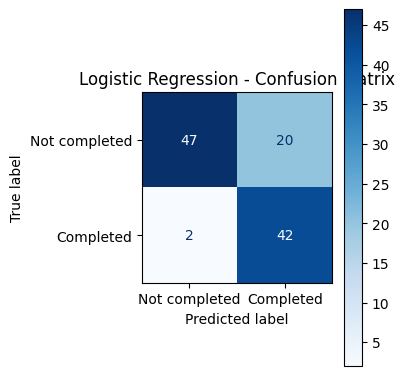

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Not completed', 'Completed'],
    cmap='Blues', ax=ax,
)
ax.set_title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

In [6]:
cv_lr = cross_validate(
    lr_pipe, X, y,
    cv=cv5,
    scoring=['accuracy', 'roc_auc', 'f1'],
    return_train_score=False,
)

print('=== Logistic Regression - 5-fold Stratified CV ===')
for metric in ['accuracy', 'roc_auc', 'f1']:
    s = cv_lr[f'test_{metric}']
    print(f'  {metric:10s}: {s.mean():.3f} +/- {s.std():.3f}   folds={np.round(s, 3)}')

=== Logistic Regression - 5-fold Stratified CV ===
  accuracy  : 0.737 +/- 0.030   folds=[0.766 0.739 0.703 0.703 0.773]
  roc_auc   : 0.810 +/- 0.037   folds=[0.781 0.82  0.758 0.823 0.865]
  f1        : 0.714 +/- 0.034   folds=[0.768 0.724 0.692 0.667 0.719]


## 5. Random Forest

Ensemble of 200 decision trees. `class_weight='balanced'` handles class imbalance.
No feature scaling needed.

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest - Hold-out Test Set ===')
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Not completed', 'Completed']
))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Random Forest - Hold-out Test Set ===
               precision    recall  f1-score   support

Not completed       0.83      0.78      0.80        67
    Completed       0.69      0.75      0.72        44

     accuracy                           0.77       111
    macro avg       0.76      0.76      0.76       111
 weighted avg       0.77      0.77      0.77       111

ROC-AUC : 0.8304


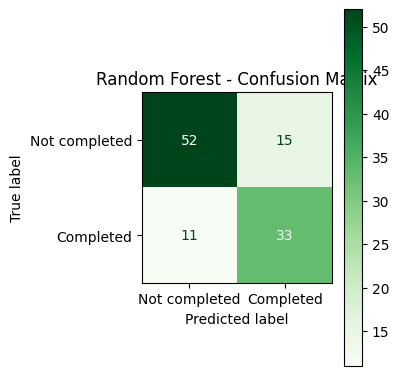

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Not completed', 'Completed'],
    cmap='Greens', ax=ax,
)
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()

In [9]:
cv_rf = cross_validate(
    rf, X, y,
    cv=cv5,
    scoring=['accuracy', 'roc_auc', 'f1'],
    return_train_score=False,
)

print('=== Random Forest - 5-fold Stratified CV ===')
for metric in ['accuracy', 'roc_auc', 'f1']:
    s = cv_rf[f'test_{metric}']
    print(f'  {metric:10s}: {s.mean():.3f} +/- {s.std():.3f}   folds={np.round(s, 3)}')

=== Random Forest - 5-fold Stratified CV ===
  accuracy  : 0.744 +/- 0.041   folds=[0.73  0.712 0.694 0.802 0.782]
  roc_auc   : 0.821 +/- 0.052   folds=[0.774 0.783 0.78  0.87  0.898]
  f1        : 0.700 +/- 0.039   folds=[0.7   0.686 0.653 0.771 0.692]


In [ ]:
importances = (
    pd.Series(rf.feature_importances_, index=X.columns)
    .sort_values(ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances - Random Forest')
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

## 6. Summary

In [10]:
summary = pd.DataFrame({
    'Logistic Regression': {
        'Accuracy (CV mean)': cv_lr['test_accuracy'].mean(),
        'Accuracy (CV std)':  cv_lr['test_accuracy'].std(),
        'ROC-AUC (CV mean)': cv_lr['test_roc_auc'].mean(),
        'ROC-AUC (CV std)':  cv_lr['test_roc_auc'].std(),
        'F1 (CV mean)':      cv_lr['test_f1'].mean(),
        'F1 (CV std)':       cv_lr['test_f1'].std(),
    },
    'Random Forest': {
        'Accuracy (CV mean)': cv_rf['test_accuracy'].mean(),
        'Accuracy (CV std)':  cv_rf['test_accuracy'].std(),
        'ROC-AUC (CV mean)': cv_rf['test_roc_auc'].mean(),
        'ROC-AUC (CV std)':  cv_rf['test_roc_auc'].std(),
        'F1 (CV mean)':      cv_rf['test_f1'].mean(),
        'F1 (CV std)':       cv_rf['test_f1'].std(),
    },
}).T.round(3)

print('=== 5-fold CV Summary - Binary: completed / not completed ===')
summary

=== 5-fold CV Summary - Binary: completed / not completed ===


,Accuracy (CV mean),Accuracy (CV std),ROC-AUC (CV mean),ROC-AUC (CV std),F1 (CV mean),F1 (CV std)
Logistic Regression,0.737,0.030,0.810,0.037,0.714,0.034
Random Forest,0.744,0.041,0.821,0.052,0.700,0.039
